In [1]:
import pandas as pd
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

I0000 00:00:1783022647.893393  524511 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783022647.921892  524511 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783022648.569838  524511 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [15]:
# TRABAJAR CON CASO 3
# 0. Cargar los metadatos de las regioes
df_val_md =  pd.read_parquet("../data/processed/test_md_caso_3.parquet")
metadata_cols = ["año", "fecha_hora", "region", "region_bne"]
df_metadata = df_val_md[metadata_cols].copy()

# 1. Cargar el modelo entrenado y el scaler de la variable "Y" (Demanda)
model = tf.keras.models.load_model('../models/best_merlin_mlp_caso_3.keras')
scaler_y = pd.read_csv('../data/models/std_scale/parametros_estandarizacion_regional.csv')
temp_scaler = joblib.load("../models/scaler_temp_caso_3.pkl")

# 2. Cargar datos de Validación (o Test)
df_scaled = df_val_md.copy()
df_scaled["target_value"] = (df_val_md['demanda_mwh'] - df_val_md['mu_total'])/df_val_md['sigma_total']
y_val_scaled = df_scaled['target_value'].values 
# temp_columns = [col for col in df_scaled.columns if 'temp' in col.lower()]
X_val_scaled = df_scaled.drop(columns=['demanda_mwh', 'target_value', 'mu_total', 'sigma_total'] + metadata_cols).values

# 3. Hacer predicciones (el resultado es un valor entre 0 y 1)
y_pred_scaled = model.predict(X_val_scaled)


3833/3833 ━━━━━━━━━━━━━━━━━━━━ 1s 341us/step


In [16]:
# 4. El Cruce: Reconstruir el DataFrame con su Datetime y REgión
df_resultados = df_metadata.copy()
df_resultados['target'] = y_val_scaled
df_resultados['predict'] = y_pred_scaled
df_resultados["mu_total"] = df_val_md['mu_total']
df_resultados["sigma_total"] = df_val_md["sigma_total"]
df_resultados["demanda_real_mwh"] = df_resultados['target']*df_resultados["sigma_total"] + df_resultados["mu_total"]
df_resultados["demanda_pred_mwh"] = df_resultados['predict']*df_resultados["sigma_total"] + df_resultados["mu_total"]
df_final = df_resultados.drop(columns=['target', 'predict'])

# Asegurarnos de que 'fecha_hora' sea datetime y extraer el año si no existe
df_final['fecha_hora'] = pd.to_datetime(df_final['fecha_hora'])
if 'año' not in df_final.columns:
    df_final['año'] = df_final['fecha_hora'].dt.year

print("Muestra de resultados por comuna y hora:")
print(df_final.head())

Muestra de resultados por comuna y hora:
    año          fecha_hora       region region_bne     mu_total  sigma_total  \
0  2021 2021-01-01 00:00:00  ANTOFAGASTA         AN  1992.686554    123.19196   
1  2021 2021-01-01 01:00:00  ANTOFAGASTA         AN  1992.686554    123.19196   
2  2021 2021-01-01 02:00:00  ANTOFAGASTA         AN  1992.686554    123.19196   
3  2021 2021-01-01 03:00:00  ANTOFAGASTA         AN  1992.686554    123.19196   
4  2021 2021-01-01 04:00:00  ANTOFAGASTA         AN  1992.686554    123.19196   

   demanda_real_mwh  demanda_pred_mwh  
0       2066.705515       1972.587569  
1       2090.701582       1963.914224  
2       2101.995280       1958.404380  
3       2082.891237       1954.438498  
4       2069.959106       1949.449394  


Métricas de Error por Región y Año:
                                   region region_bne   año  RMSE (MWh)  \
7                               LOS LAGOS         LL  2021   26.501454   
2                                 ATACAMA         AT  2021   44.258562   
5                            LA ARAUCANÍA         AR  2021   19.040984   
1                      ARICA Y PARINACOTA         AP  2021    4.538614   
9                                   MAULE         ML  2021   33.307844   
11                               TARAPACÁ         TA  2021   25.219296   
13                                  ÑUBLE         NB  2021   10.408629   
10              METROPOLITANA DE SANTIAGO         RM  2021  217.153785   
6   LIBERTADOR GENERAL BERNARDO O'HIGGINS         LI  2021   42.882124   
3                                  BIOBÍO         BI  2021   40.468090   
4                                COQUIMBO         CO  2021   15.757550   
8                                LOS RÍOS         LR  2021    7.277212   
0 

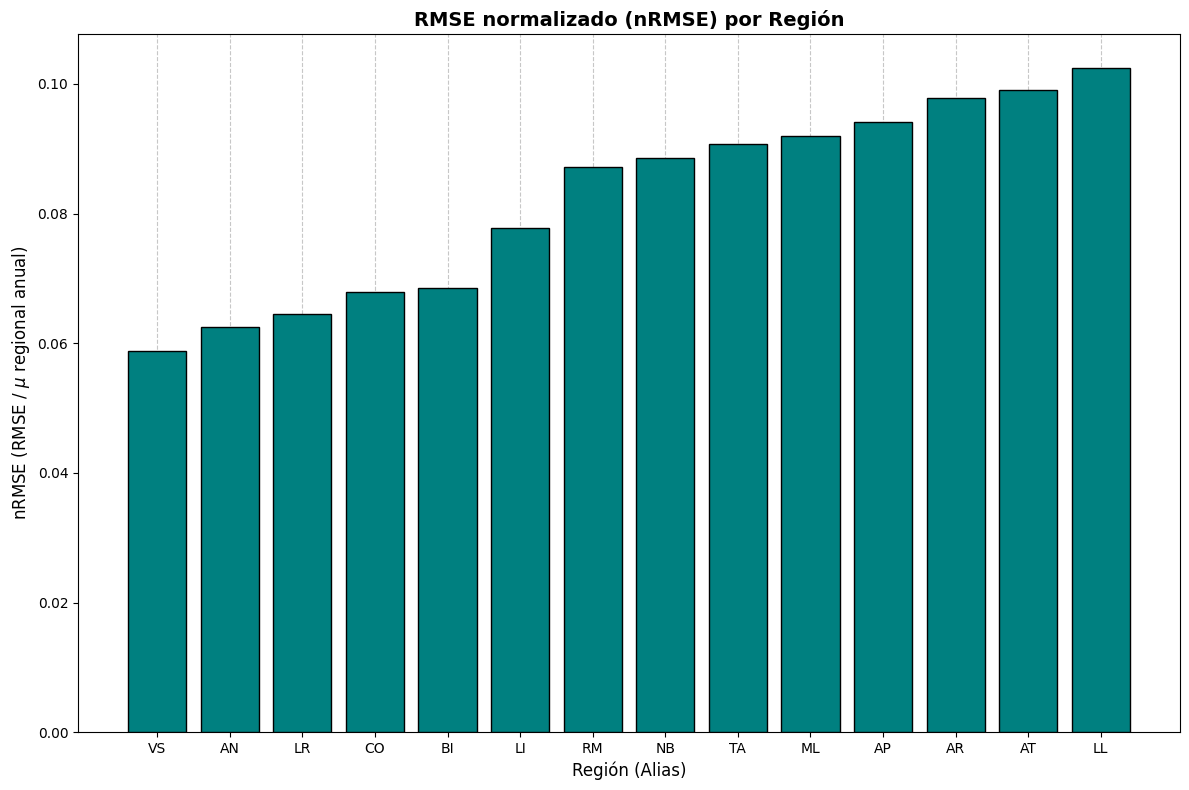

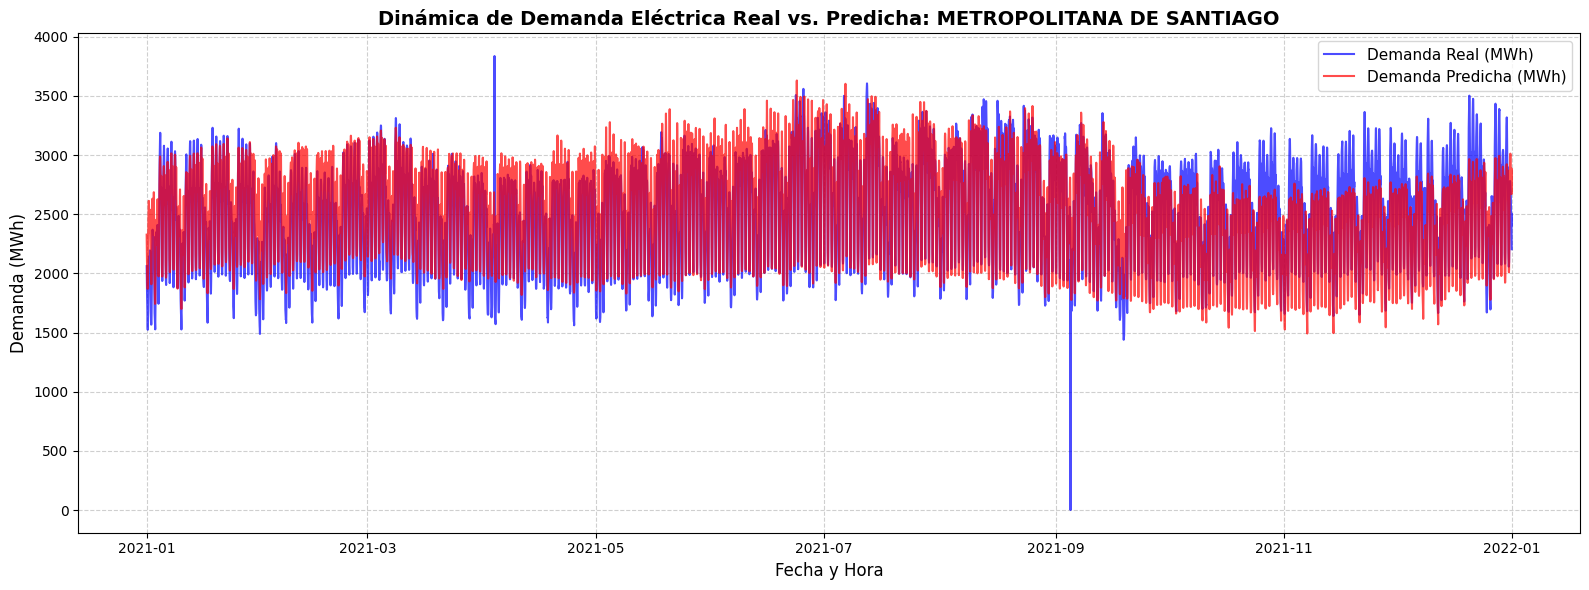

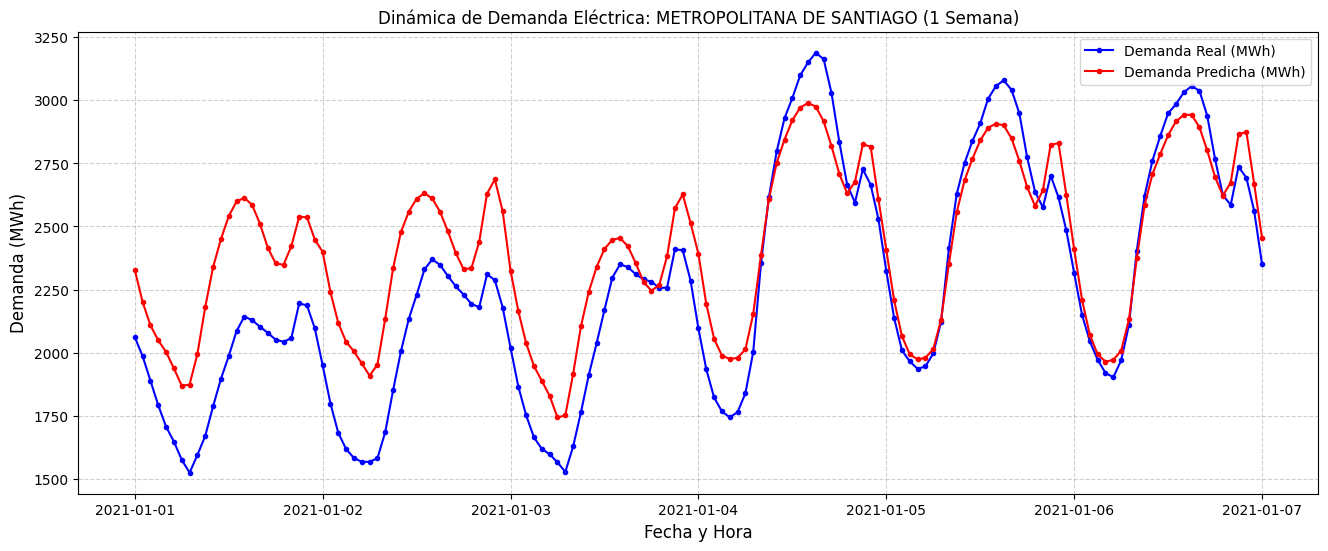

In [36]:
# Definimos una función auxiliar para calcular las métricas por grupo
def calcular_metricas(grupo):
    y_real = grupo['demanda_real_mwh']
    y_pred = grupo['demanda_pred_mwh']
    
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    
    # El mu_total es el mismo para toda la región en un mismo año. Tomamos el primer valor.
    mu_region_ano = grupo['mu_total'].iloc[0]
    
    # Calculamos NRMSE
    nrmse = rmse / mu_region_ano if mu_region_ano != 0 else np.nan
    
    return pd.Series({'RMSE (MWh)': rmse, 'MAE (MWh)': mae, 'NRMSE': nrmse})

# Agrupamos por region, region_bne y año
df_metricas_regionales = df_final.groupby(['region', 'region_bne', 'año']).apply(calcular_metricas).reset_index()

# Ordenamos por NRMSE para ver qué regiones tienen mayor/menor error relativo
df_metricas_regionales = df_metricas_regionales.sort_values(by='NRMSE', ascending=False)

print("Métricas de Error por Región y Año:")
print(df_metricas_regionales)
print("\n" + "="*50 + "\n")


# ---------------------------------------------------------
# 2. GRAFICAR NRMSE POR REGIÓN (ALIAS BNE)
# ---------------------------------------------------------

plt.figure(figsize=(12, 8))

# Creamos una etiqueta que incluya el alias BNE y el año (por si validas más de un año a la vez)
etiquetas_bne = df_metricas_regionales['region_bne'] 
valores_nrmse = df_metricas_regionales['NRMSE']

# Usamos barras horizontales e invertimos el orden para que la barra más grande quede arriba
plt.bar(etiquetas_bne[::-1], valores_nrmse[::-1], color='teal', edgecolor='black', zorder=10)

plt.title('RMSE normalizado (nRMSE) por Región', fontsize=14, fontweight='bold')
plt.ylabel('nRMSE (RMSE / $\mu$ regional anual)', fontsize=12)
plt.xlabel('Región (Alias)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7, zorder=0)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 2. GRAFICAR LA DINÁMICA DE LA REGIÓN METROPOLITANA
# ---------------------------------------------------------

# Asegurarnos de que 'fecha_hora' sea un objeto datetime para que el eje X del gráfico se ordene bien
df_final['fecha_hora'] = pd.to_datetime(df_final['fecha_hora'])

# Filtrar solo los datos de la región de interés
region_interes = "METROPOLITANA DE SANTIAGO"
df_rm = df_final[df_final['region'] == region_interes].copy()

# Ordenar cronológicamente por si los datos están desordenados
df_rm = df_rm.sort_values(by='fecha_hora')

# Crear el gráfico
plt.figure(figsize=(16, 6))

# Trazar las líneas de demanda real y predicha
plt.plot(df_rm['fecha_hora'], df_rm['demanda_real_mwh'], label='Demanda Real (MWh)', color='blue', alpha=0.7, linewidth=1.5)
plt.plot(df_rm['fecha_hora'], df_rm['demanda_pred_mwh'], label='Demanda Predicha (MWh)', color='red', alpha=0.7, linewidth=1.5)

# Configuraciones visuales del gráfico
plt.title(f'Dinámica de Demanda Eléctrica Real vs. Predicha: {region_interes}', fontsize=14, fontweight='bold')
plt.xlabel('Fecha y Hora', fontsize=12)
plt.ylabel('Demanda (MWh)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

# Opcional: Si los datos de validación cubren muchos meses, el gráfico puede verse muy "denso".
# Puedes graficar solo una semana específica descomentando las siguientes líneas:

fecha_inicio = '2021-01-01' # Cambia según tu dataset
fecha_fin = '2021-01-07'
df_rm_semana = df_rm[(df_rm['fecha_hora'] >= fecha_inicio) & (df_rm['fecha_hora'] <= fecha_fin)]

plt.figure(figsize=(16, 6))
plt.plot(df_rm_semana['fecha_hora'], df_rm_semana['demanda_real_mwh'], label='Demanda Real (MWh)', color='blue', marker='.')
plt.plot(df_rm_semana['fecha_hora'], df_rm_semana['demanda_pred_mwh'], label='Demanda Predicha (MWh)', color='red', marker='.')
plt.title(f'Dinámica de Demanda Eléctrica: {region_interes} (1 Semana)')
plt.xlabel('Fecha y Hora', fontsize=12)
plt.ylabel('Demanda (MWh)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [20]:
# Desagegación sectorial
sectores = ['R', 'C', 'P', 'I', 'T']

df_des = df_final.copy()

for sector in sectores: 
    print(f"Desagregando resultados en sector {sector}")
    df_dum = df_scaled.copy()
    key_1 = f"share_{sector}"
    # 0. Tomar la columna del share del sector respectivo y hacerla cero
    df_dum[key_1] = 0.
    # 1. Extraer inputs del modelo
    X_val_scaled = df_dum.drop(columns=['demanda_mwh', 'target_value', 'mu_total', 'sigma_total'] + metadata_cols).values
    # 2. Agregar mu y sigma calculado sin el sector
    cols_scaler = [f"mu_sin_{sector}", f"sigma_sin_{sector}"] + ["región", "año"]
    mu_std = scaler_y[cols_scaler]
    mu_std.rename(columns={"región": "region_bne"}, inplace=True)
    # Junta los dataframes para tener todos los datos
    df_dum_completo = pd.merge(df_final, mu_std, on=["año", "region_bne"])
    # 3. Hacer predicciones (el resultado es un valor entre 0 y 1)
    y_pred_s_sector = model.predict(X_val_scaled)
    df_dum_completo[f"pred_s_{sector}"] = y_pred_s_sector
    # 4. Integrar la predicción sectorial
    key_2 = f"pred_sin_{sector}_mwh"
    df_des[key_2] = df_dum_completo[f"pred_s_{sector}"]*df_dum_completo[f"sigma_sin_{sector}"] + df_dum_completo[f"mu_sin_{sector}"] 
    # 5. Obtener el valor del sector
    df_final[f"demanda_pred_{sector}_mwh"] = df_final["demanda_pred_mwh"] - df_des[key_2]

Desagregando resultados en sector R
 175/3833 ━━━━━━━━━━━━━━━━━━━━ 1s 287us/step

3833/3833 ━━━━━━━━━━━━━━━━━━━━ 1s 290us/step
Desagregando resultados en sector C
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 1s 300us/step
Desagregando resultados en sector P
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 1s 312us/step
Desagregando resultados en sector I
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 1s 284us/step
Desagregando resultados en sector T
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 1s 290us/step


In [27]:
def graficar_demanda_areas_apiladas(df, nombre_region):
    # 1. Filtrar y preparar fechas
    df_region = df[df['region'] == nombre_region].copy()
    df_region['fecha_hora'] = pd.to_datetime(df_region['fecha_hora'])
    df_region = df_region.sort_values('fecha_hora')
    
    # 2. Definir las columnas de los sectores y sus etiquetas
    columnas_sectores = [
        'demanda_pred_R_mwh', 'demanda_pred_C_mwh', 
        'demanda_pred_P_mwh', 'demanda_pred_I_mwh', 'demanda_pred_T_mwh'
    ]
    etiquetas = ['Residencial (R)', 'Comercial (C)', 'Público (P)', 'Industrial (I)', 'Transporte (T)']
    colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'] # Paleta de colores estándar
    
    # 3. Extraer las series en una lista (se asume que los valores nulos ya son 0)
    y_sectores = [df_region[col].fillna(0) for col in columnas_sectores]
    
    # 4. Crear la figura
    plt.figure(figsize=(14, 6))
    
    # Dibujar áreas apiladas
    plt.stackplot(df_region['fecha_hora'], y_sectores, 
                  labels=etiquetas, colors=colores, alpha=0.85)

    
    # 5. Formato del gráfico
    plt.title(f'Desagregación Sectorial - Región: {nombre_region}', fontsize=14)
    plt.xlabel('Fecha y Hora', fontsize=12)
    plt.ylabel('Demanda Estimada (MWh)', fontsize=12)
    
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

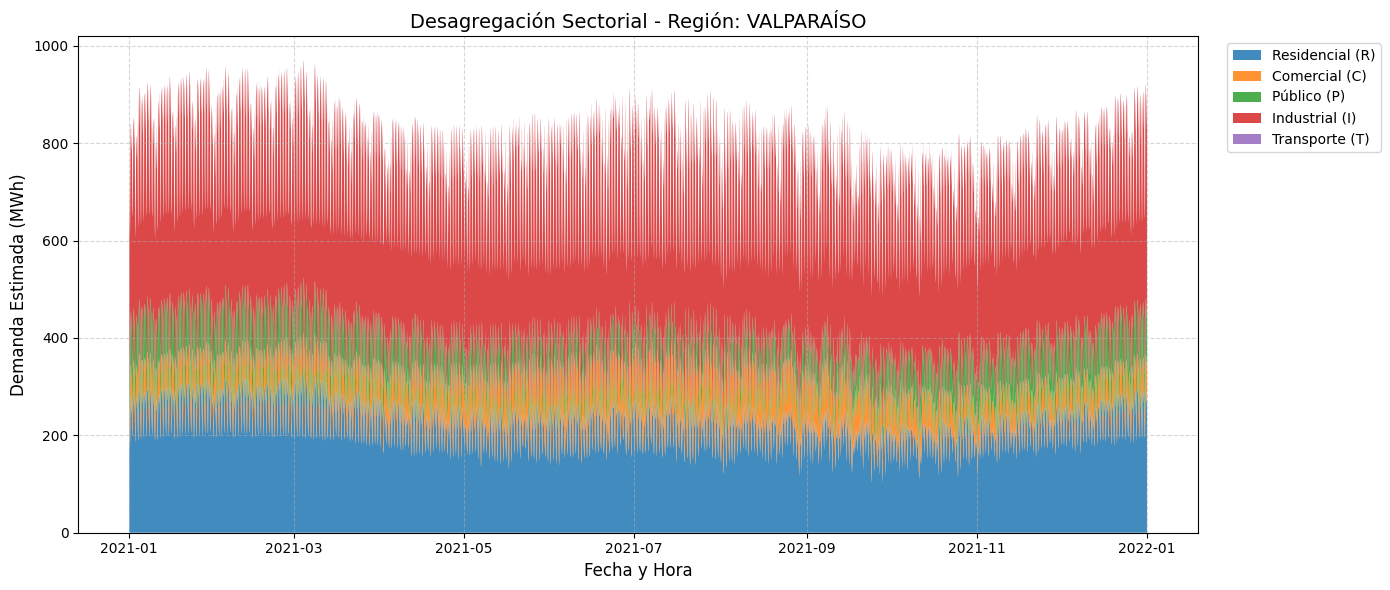

In [33]:
# --- EJEMPLO DE USO ---
graficar_demanda_areas_apiladas(df_final, 'VALPARAÍSO')

In [42]:
def obtener_totales_anuales_sectoriales(df):
    df_calc = df.copy()
    
    # Si no existe la columna 'año', la creamos a partir de 'fecha_hora'
    if 'año' not in df_calc.columns:
        df_calc['fecha_hora'] = pd.to_datetime(df_calc['fecha_hora'])
        df_calc['año'] = df_calc['fecha_hora'].dt.year

    # Definir qué columnas vamos a sumar
    columnas_a_sumar = [
        'demanda_pred_mwh',       # Total global
        'demanda_pred_R_mwh', 
        'demanda_pred_C_mwh', 
        'demanda_pred_P_mwh', 
        'demanda_pred_I_mwh', 
        'demanda_pred_T_mwh'
    ]
    
    # Agrupar por año y región, y sumar los MWh
    df_totales = df_calc.groupby(['año', 'region_bne'])[columnas_a_sumar].sum().reset_index()
    
    # (Opcional) Renombrar las columnas para que la tabla sea más limpia al exportarla
    df_totales.rename(columns={
        'demanda_pred_mwh': 'Total_Predicho_MWh',
        'demanda_pred_R_mwh': 'Sector_Residencial_MWh',
        'demanda_pred_C_mwh': 'Sector_Comercial_MWh',
        'demanda_pred_P_mwh': 'Sector_Publico_MWh',
        'demanda_pred_I_mwh': 'Sector_Industrial_MWh',
        'demanda_pred_T_mwh': 'Sector_Transporte_MWh'
    }, inplace=True)
    
    return df_totales

In [43]:
# --- EJEMPLO DE USO ---
df_totales_anuales = obtener_totales_anuales_sectoriales(df_final)

# Ver las primeras filas de los resultados
display(df_totales_anuales.head())

,año,region_bne,Total_Predicho_MWh,Sector_Residencial_MWh,Sector_Comercial_MWh,Sector_Publico_MWh,Sector_Industrial_MWh,Sector_Transporte_MWh
0,2021,AN,1.747994e+07,4.514534e+05,234901.815477,31710.534268,1.628028e+07,453602.986598
1,2021,AP,4.212377e+05,1.947775e+05,63178.914964,29383.284358,1.244269e+05,0.000000
2,2021,AR,1.718894e+06,5.398972e+05,206652.217967,81342.527090,8.740785e+05,310.226401
3,2021,AT,3.898243e+06,2.179955e+05,101628.757995,34605.710302,3.522206e+06,0.000000
4,2021,BI,5.179369e+06,1.087256e+06,309887.254407,272712.851834,3.482772e+06,6787.514546


In [37]:
# ==========================================
# 1. PREPARAR DATOS DEL BALANCE REGIONAL (BRE)
# ==========================================
# Cargar BRE y filtrar solo el año de validación (2021)
data_bre = pd.read_csv("../data/raw/wp2_elec_input_sector_shares_raw.csv")
df_bre_2021 = data_bre[data_bre["año"] == 2021].copy()

# Pivotear
df_sec = df_bre_2021.pivot_table(
    index="región", columns="sector", values="valor", aggfunc="sum"
).reset_index()

# Calcular el total de la BRE (TWh). Suponiendo que 'valor' está en GWh, se divide por 1e3
sectores = ["Industrial", "Residencial", "Comercial", "Público", "Transporte"]
sectores_presentes = [
    s for s in sectores if s in df_sec.columns
]  # Evita errores si falta algún sector
df_sec["total_BRE_TWh"] = df_sec[sectores_presentes].sum(axis=1) / 1e3

# Ver las primeras filas de los resultados
display(df_sec.head())

sector,región,Comercial,Industrial,Público,Residencial,Transporte,total_BRE_TWh
0,AI,34.657367,78.521672,9.839641,81.865733,NaN,0.204884
1,AN,234.375706,16282.149404,32.283770,465.493024,442.129510,17.456431
2,AP,53.397788,101.872525,23.662223,154.566007,NaN,0.333499
3,AR,260.517511,1071.127827,107.786295,627.389096,0.418753,2.067239
4,AT,85.107988,2936.808578,29.679758,185.874361,NaN,3.237471


<Figure size 1600x700 with 0 Axes>

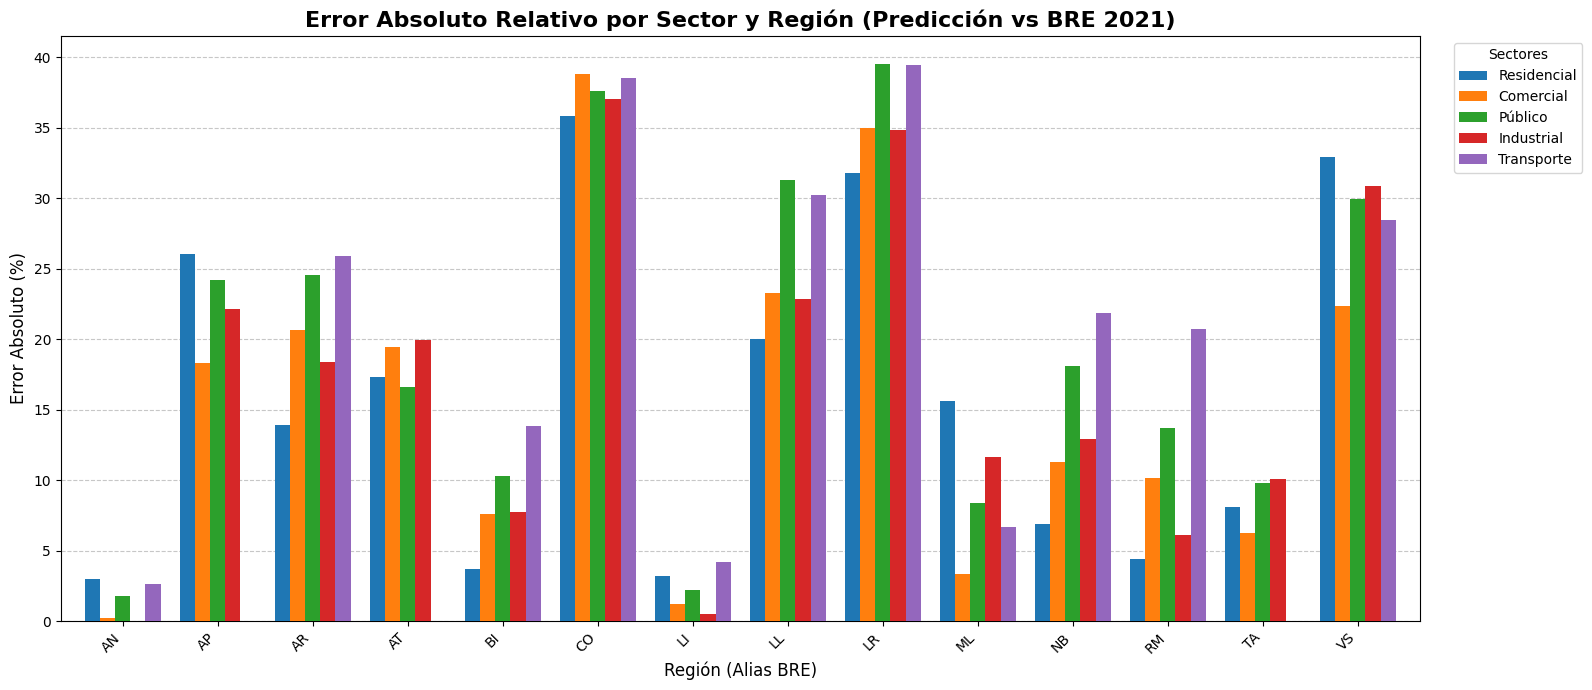

In [50]:
# ==========================================
# 2. CALCULAR ERROR Y GRAFICAR
# ==========================================

# 1. Filtrar las predicciones totales solo para 2021 (asumiendo que tienes la columna 'año')
# NOTA: Asegúrate de que df_totales_anuales tenga la columna con el alias del BRE. 
# Si tu columna se llama 'region_bne', usa esa.
df_pred_2021 = df_totales_anuales[df_totales_anuales['año'] == 2021].copy()

# 2. Unir ambos DataFrames usando el nombre de la región
# Ajusta 'region_bne' por el nombre de la columna en df_pred_2021 que tenga los nombres homologados
df_comparacion = pd.merge(
    df_sec, 
    df_pred_2021, 
    left_on="región",      # Columna en el DataFrame del BRE
    right_on="region_bne",     # Columna en tus predicciones (cambiar a 'region_bne' si corresponde)
    how="inner"
)

# 3. Diccionario para mapear las columnas del BRE con las columnas de Predicción
mapeo_sectores = {
    'Residencial': 'Sector_Residencial_MWh',
    'Comercial': 'Sector_Comercial_MWh',
    'Público': 'Sector_Publico_MWh',
    'Industrial': 'Sector_Industrial_MWh',
    'Transporte': 'Sector_Transporte_MWh'
}

columnas_error = []

# 4. Calcular el Error Absoluto Relativo para cada sector
for sector_bre, col_pred in mapeo_sectores.items():
    if sector_bre in df_comparacion.columns and col_pred in df_comparacion.columns:
        nombre_err = f'Error_{sector_bre}'
        columnas_error.append(nombre_err)
        
        # Convertir Predicción de MWh a GWh para igualar al BRE
        pred_gwh = df_comparacion[col_pred] / 1000.0
        val_bre = df_comparacion[sector_bre]
        
        # Calcular abs(pred - bre) / bre
        # Usamos np.where para evitar errores de división por cero si algún sector en el BRE es 0
        df_comparacion[nombre_err] = np.where(
            val_bre > 0, 
            np.abs(pred_gwh - val_bre) / val_bre, 
            0 
        )

# 5. Preparar los datos para el gráfico (fijar la región como índice)
df_grafico = df_comparacion.set_index("región")[columnas_error]

# Multiplicamos por 100 para visualizar el error en Porcentaje (%)
df_grafico_pct = df_grafico * 100 

# 1. Definir la paleta de colores (la estándar 'tab10' de Matplotlib)
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# 2. Crear el Gráfico de Barras Agrupadas usando el parámetro 'color'
plt.figure(figsize=(16, 7))

# Reemplazamos colormap='Set2' por color=colores
ax = df_grafico_pct.plot(kind='bar', figsize=(16, 7), width=0.8, color=colores, zorder=10)

# Formatear el gráfico
plt.title('Error Absoluto Relativo por Sector y Región (Predicción vs BRE 2021)', fontsize=16, fontweight='bold')
plt.xlabel('Región (Alias BRE)', fontsize=12)
plt.ylabel('Error Absoluto (%)', fontsize=12)

# Limpiar los nombres de la leyenda (quitar la palabra "Error_")
etiquetas_limpias = [col.replace('Error_', '') for col in df_grafico_pct.columns]
ax.legend(etiquetas_limpias, title='Sectores', bbox_to_anchor=(1.02, 1), loc='upper left')

# Ajustar visualización del eje X y grilla
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

plt.tight_layout()
plt.show()